In [1]:
%matplotlib widget
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from snntorch.surrogate import fast_sigmoid

import numpy as np
from tqdm.auto import tqdm
import psutil, os

from thesis_code import SRNN, datasets
import thesis_code.training as tr
from thesis_code.network_components.layers import StandardRecurrentLayer
from thesis_code.recording import SpikeRecorder, PerformanceRecorder, GradientRecorder
# from thesis_code.connectivity import sample_ee_pv_som_neurons
from thesis_code.decay_sampling import sample_heterogeneous_decays_normal, tau_to_beta
from thesis_code.runs import generate_run_id, get_git_commit, save_run, push_run

In [2]:
flushing = torch.set_flush_denormal(True)
print(f"Floating point flushing is set to {flushing}")

torch.manual_seed(42)
torch.set_num_threads(4)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Floating point flushing is set to True
Using device: cuda


In [3]:
def train_net(net: SRNN, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None, separate_timesteps: bool = False,
        regularizer: tr.Regularizer = None, grad_rec: GradientRecorder = None, spk_rec: SpikeRecorder = None,
    ) -> tuple[nn.Module, PerformanceRecorder, GradientRecorder | None, SpikeRecorder | None]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    process = psutil.Process(os.getpid())
    perf_rec = PerformanceRecorder()

    use_amp = device.type == "cuda"

    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        losses, accs = [], []
        for i, (data, targets) in progress_bar:

            forward_fn = net.forward_sequence if separate_timesteps else net
            with torch.autocast(device.type, dtype=torch.bfloat16, enabled=use_amp):
                spk_outs, mem_outs, hidden_spks = forward_fn(data)

            loss_val = tr.compute_loss(mem_outs, targets)
            
            if regularizer is not None:
                loss_val = loss_val +  regularizer(hidden_spks)

            if spk_rec is not None:
                spk_rec.record(data, hidden_spks, spk_outs, targets)

            optimizer.zero_grad()
            loss_val.backward()

            if grad_rec is not None:
                grad_rec.record(net)

            optimizer.step()

            losses.append(loss_val.item())
            acc = tr.measure_accuracy(mem_outs.detach(), targets)
            accs.append(acc)

            progress_bar.set_postfix(
                loss=f"{loss_val.item():.2f}",
                acc=f"{acc * 100:.2f}%",
                time_elapsed=f"{progress_bar.format_dict['elapsed']:.1f}s",
                used_memory=f"{process.memory_info().rss / 1e9:.2f} GB",
            )

            if max_iters is not None and i == max_iters:
                break

        perf_rec.record(float(np.mean(losses)), float(np.mean(accs)))
    return net, perf_rec, grad_rec, spk_rec

In [4]:
dt = 0.01     # Timesteps are in milliseconds
batch_size = 128
SHD_trainloader, SHD_testloader, input_dim, classes = datasets.get_SHD_dataset(batch_size, device, time_window=10000)

In [5]:
ns_hidden = [256, 256]
layers = [input_dim] + ns_hidden

# neurons = sample_ee_pv_som_neurons(ns_hidden, percent_pv=25.0, percent_som=25.0)
net = SRNN(
    rec_layers=[
        StandardRecurrentLayer(
            forward_matrix=torch.ones(n_prev, n),
            recurrent_matrix=torch.ones(n, n),
            beta=sample_heterogeneous_decays_normal(dt, n, tau_mean=10 * dt, tau_std=1 * dt, device=device),
            spike_grad=fast_sigmoid(slope=25),
        ) for n_prev, n in zip(layers[:-1], layers[1:])],
    beta_out=tau_to_beta(dt, 20 * dt),
    n_classes=len(classes),
).to(device)

regularizer = tr.Regularizer(lam_lower=100.0, v_lower=1e-2, lam_uppers=[0.5, 0.5], v_uppers=[50, 50], L=2)

In [6]:
import time

it = iter(SHD_trainloader)
for _ in range(3):
    t0 = time.perf_counter(); data, targets = next(it);               t_load = time.perf_counter() - t0
    t0 = time.perf_counter(); spk, mem, hid = net.forward_sequence(data);               t_fwd = time.perf_counter() - t0
    t0 = time.perf_counter(); loss = tr.compute_loss(mem, targets)
    if regularizer is not None: loss = loss + regularizer(hid)
    loss.backward();                                                   t_bwd = time.perf_counter() - t0
    print(f"load {t_load:.2f}s  fwd {t_fwd:.2f}s  loss+bwd {t_bwd:.2f}s  T={data.shape[0]}", flush=True)

load 0.15s  fwd 0.22s  loss+bwd 0.55s  T=103
load 0.13s  fwd 0.07s  loss+bwd 0.05s  T=120
load 0.13s  fwd 0.06s  loss+bwd 0.04s  T=103


In [7]:
net.eval()
with torch.no_grad():
    _, m_old, _ = net(data)
    _, m_new, _ = net.forward_sequence(data)
print(torch.allclose(m_old, m_new, atol=1e-5), (m_old - m_new).abs().max().item())

True 5.7220458984375e-06


In [8]:
acc_before = tr.test_net(net, testloader=SHD_testloader)
print(f"Test Accuracy before training is: {acc_before}")

net, perf_rec, grad_rec, spk_rec = train_net(
    net=net,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
    separate_timesteps=False,
    regularizer=regularizer,
    grad_rec=GradientRecorder(),
    # spk_rec=SpikeRecorder(num_hidden_layers=len(ns_hidden)),
)

acc_after = tr.test_net(net, testloader=SHD_testloader)
print(f"Test Accuracy after training is: {acc_after}")

Test Accuracy before training is: 0.049834280378288694


Epoch 0:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 6:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 7:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 8:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9:   0%|          | 0/63 [00:00<?, ?it/s]

Test Accuracy after training is: 0.7286931839254167


In [11]:
cfg = {
    "git_commit": get_git_commit(),
    "net": {},            # whatever SRNN(...) takes
    "ns_hidden": ns_hidden,
    "lr": 1e-3, "n_epochs": 50,
    "test_acc_before": acc_before, "test_acc_after": acc_after,
}
run_id = generate_run_id()
run_dir = save_run(run_id, cfg, net, perf_rec=perf_rec, grad_rec=grad_rec, spk_rec=spk_rec)
print(f"Saved output to: {run_dir}")
push_run(run_dir, run_id, cfg)

Saved output to: C:\Users\Emiel\Documents\Study\AI_x_CNS\Thesis\Thesis-Code\_runs_tmp\run-20261001-231317-996e77-j_luotmy


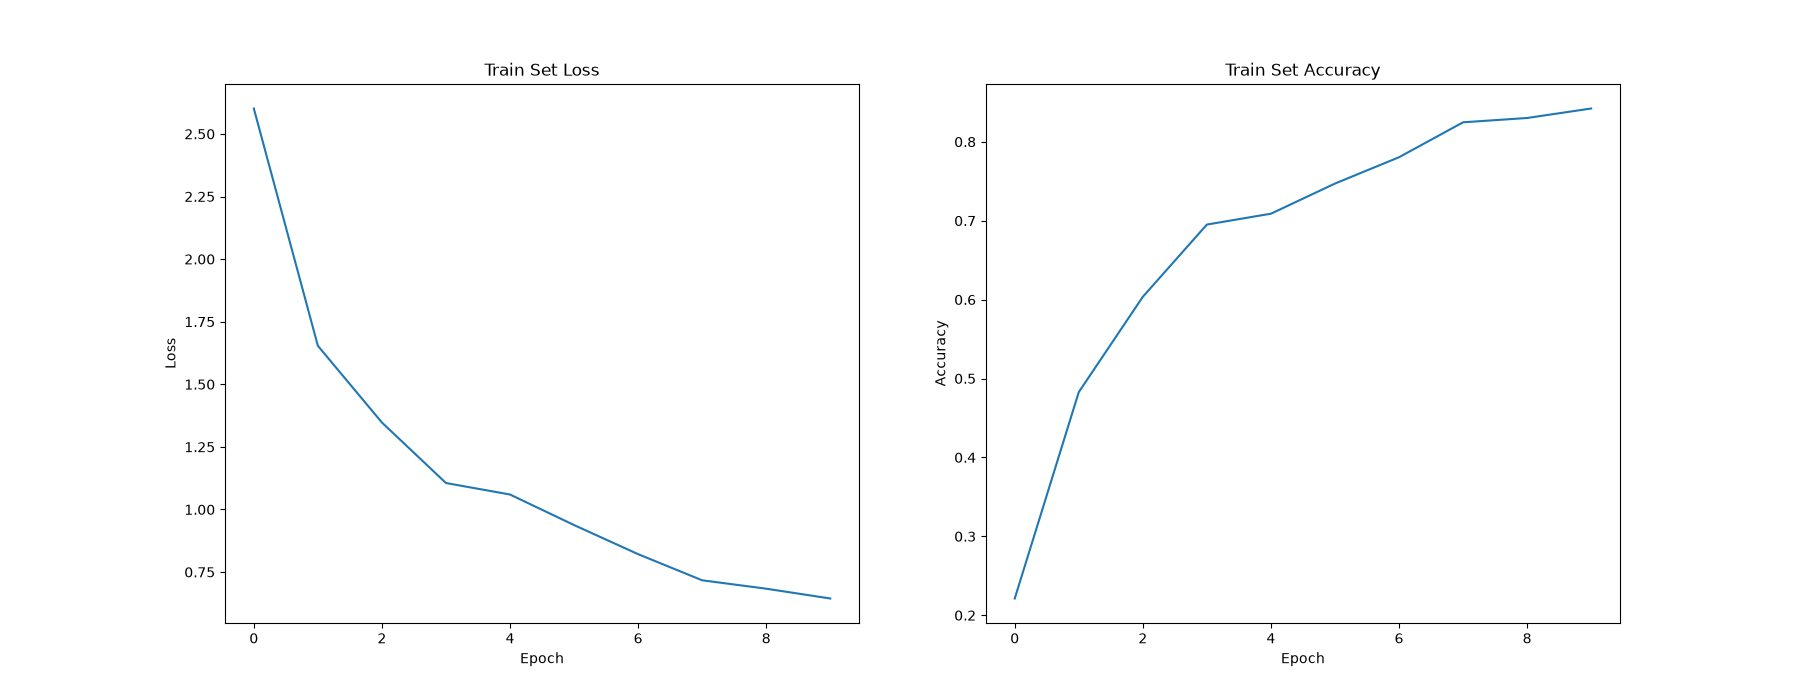

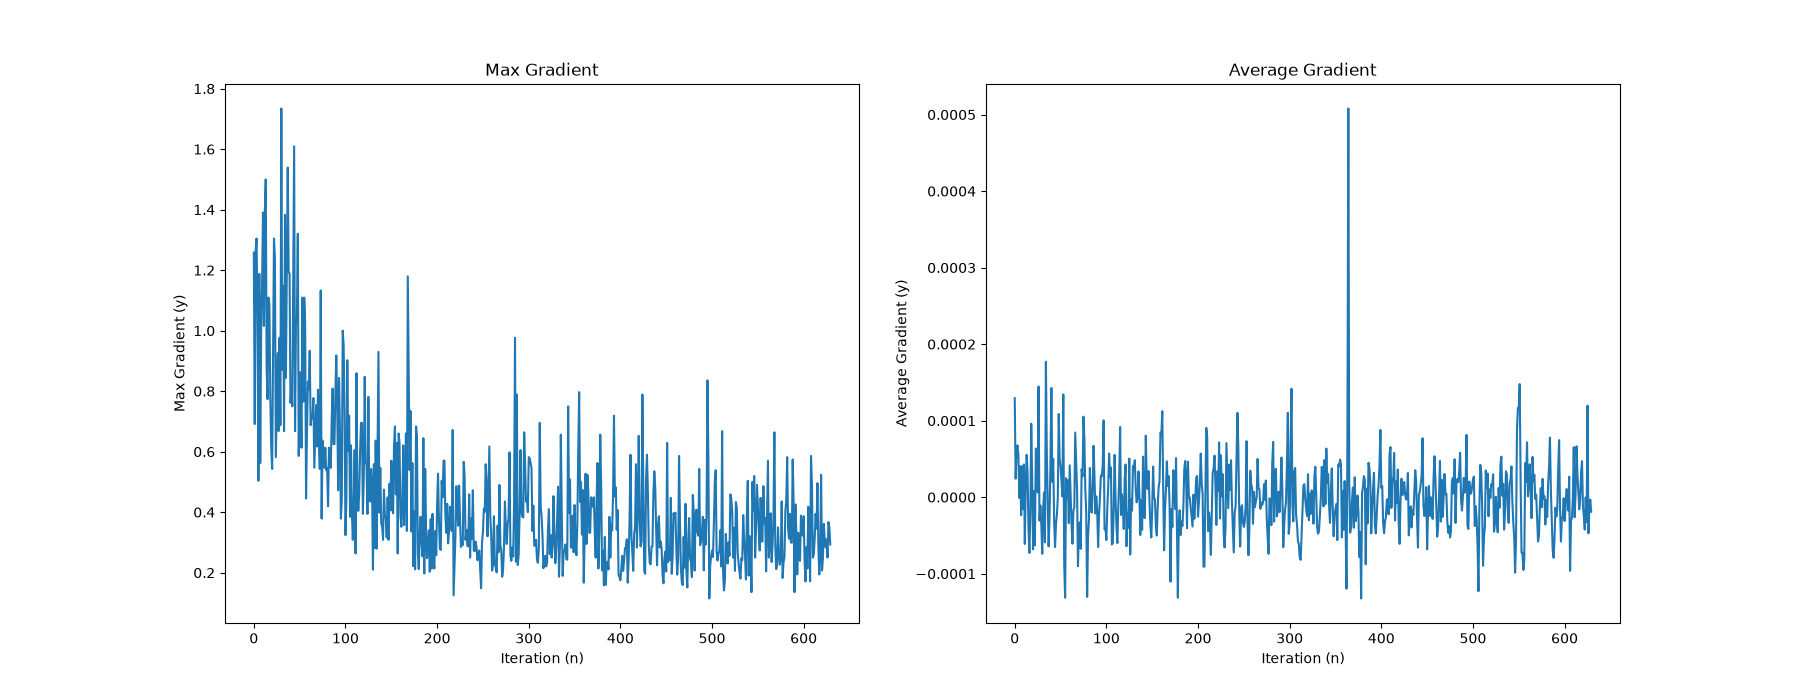

In [10]:
from thesis_code.plotting import plot_performance, plot_gradients, InteractiveSpikePlot

plot_performance(perf_rec)
plot_gradients(grad_rec)